In [ ]:
import numpy as np
from qiskit.circuit import QuantumCircuit, Parameter
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator as Estimator
from scipy.optimize import minimize

# 1. Define the Hamiltonian using SparsePauliOp
# hamiltonian = SparsePauliOp.from_list([
#     ("ZI", 1.0),
#     ("IZ", 1.0),
#     ("XX", 0.5)
# ])
hamiltonian = SparsePauliOp.from_list([
    ("XX", 1.0)
])
# 2. Define the ansatz
theta1 = Parameter('θ₁')
theta2 = Parameter('θ₂')
qc = QuantumCircuit(2)
qc.ry(theta1, 0)
qc.rz(theta2, 1)
qc.cx(0, 1)

# 3. Instantiate an Estimator primitive
estimator = Estimator()

# Pre-calculate the H^2 operator for variance calculation
h2_op = (hamiltonian @ hamiltonian).simplify()


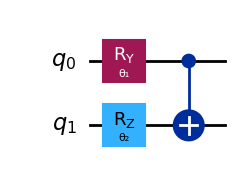

In [17]:
qc.draw('mpl')

In [18]:
qc0 = qc.copy()
qc0 = qc0.assign_parameters({theta1: 0, theta2: 0})  # Initialstat binding to avoid unbound parameters

from qiskit.quantum_info import Statevector
initial_state = Statevector.from_instruction(qc0)


In [19]:
initial_state

Statevector([1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
            dims=(2, 2))


In [20]:

# --- VQE Logic ---

# Lists to store intermediate values during optimization
energies = []
variances = []
parameters = []

# 4. Calculation function using the Estimator
def get_energy_and_variance(params):
    """Calculates energy and variance for a given set of parameters."""
    # FIX: Use the V2 Estimator interface, passing a list of jobs (tuples).
    # The format is [(circuit, [observables], parameter_values), ...]
    job = estimator.run([(qc, [hamiltonian, h2_op], params)])
    
    result = job.result()
    
    # The result object's structure is also slightly different
    energy = result[0].data.evs[0] # Result for the first observable
    h2 = result[0].data.evs[1]     # Result for the second observable
    
    variance = np.real(h2 - energy**2)
    
    return energy, variance**0.5

# Define the objective function for the optimizer
def objective_function(params):
    """The function we want to minimize."""
    energy, _ = get_energy_and_variance(params)
    return energy

# Define a callback function to observe the optimization progress
def callback(params):
    """A function called at each iteration of the optimizer."""
    energy, variance = get_energy_and_variance(params)
    energies.append(energy)
    variances.append(variance)
    parameters.append(params)
    print(f"Params: {params}, Energy: {energy:.6f}, Variance: {variance:.6f}")

# --- Run the Optimization ---

# Set initial parameters randomly
# init_params = np.random.rand(2) * 2 * np.pi  # Random initial parameters in [0, 2π]
init_params = [0.0, 0.0]  # Fixed initial parameters for reproducibility
print("Starting VQE optimization...")

# Use scipy.optimize.minimize to find the optimal parameters
result = minimize(objective_function, init_params, method='COBYLA', callback=callback)

# --- Final Results ---

# Calculate final values with the optimal parameters found by the optimizer
final_energy, final_variance = get_energy_and_variance(result.x)

print("\n optimization complete.")
print(f"Optimal parameters: {result.x}")
print(f"Ground state energy: {final_energy:.6f}")
print(f"Variance at ground state: {final_variance:.6f}")

Starting VQE optimization...
Params: [-1.  0.], Energy: -0.841471, Variance: 0.540302
Params: [-1.  0.], Energy: -0.841471, Variance: 0.540302
Params: [-1.  0.], Energy: -0.841471, Variance: 0.540302
Params: [-1.49926741 -0.02705647], Energy: -0.997443, Variance: 0.071468
Params: [-1.53609222 -0.14650911], Energy: -0.999398, Variance: 0.034697
Params: [-1.58387328 -0.13177919], Energy: -0.999914, Variance: 0.013077
Params: [-1.58387328 -0.13177919], Energy: -0.999914, Variance: 0.013077
Params: [-1.57827328 -0.08209378], Energy: -0.999972, Variance: 0.007477
Params: [-1.57716484 -0.07721819], Energy: -0.999980, Variance: 0.006368
Params: [-1.56726788 -0.07865004], Energy: -0.999994, Variance: 0.003528
Params: [-1.56726788 -0.07865004], Energy: -0.999994, Variance: 0.003528
Params: [-1.56727264 -0.08365003], Energy: -0.999994, Variance: 0.003524
Params: [-1.56727429 -0.08415003], Energy: -0.999994, Variance: 0.003522
Params: [-1.56827429 -0.08414916], Energy: -0.999997, Variance: 0.0025

Step 1: change1 = 0.000000, change2 = 0.000000, Variance = 0.540302
Step 2: change1 = 0.000000, change2 = 0.000000, Variance = 0.540302
Step 3: change1 = 0.499267, change2 = 0.027056, Variance = 0.071468
Step 4: change1 = 0.036825, change2 = 0.119453, Variance = 0.034697
Step 5: change1 = 0.047781, change2 = 0.014730, Variance = 0.013077
Step 6: change1 = 0.000000, change2 = 0.000000, Variance = 0.013077
Step 7: change1 = 0.005600, change2 = 0.049685, Variance = 0.007477
Step 8: change1 = 0.001108, change2 = 0.004876, Variance = 0.006368
Step 9: change1 = 0.009897, change2 = 0.001432, Variance = 0.003528
Step 10: change1 = 0.000000, change2 = 0.000000, Variance = 0.003528
Step 11: change1 = 0.000005, change2 = 0.005000, Variance = 0.003524
Step 12: change1 = 0.000002, change2 = 0.000500, Variance = 0.003522
Step 13: change1 = 0.001000, change2 = 0.000001, Variance = 0.002522
Step 14: change1 = 0.001000, change2 = 0.000001, Variance = 0.001522
Step 15: change1 = 0.000709, change2 = 0.00

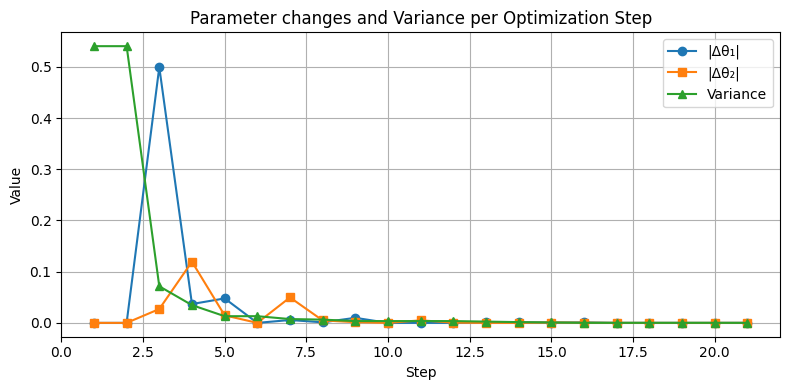

In [21]:
parameters = np.asarray(parameters)
n_steps = len(parameters) - 1

del_par0 = []
del_par1 = []

for i in range(n_steps):
    d0 = abs(parameters[i][0] - parameters[i+1][0])
    d1 = abs(parameters[i][1] - parameters[i+1][1])
    del_par0.append(d0)
    del_par1.append(d1)
    print(f"Step {i+1}: change1 = {d0:.6f}, change2 = {d1:.6f}, Variance = {variances[i+1]:.6f}")

import matplotlib.pyplot as plt
x = np.arange(1, n_steps + 1)

plt.figure(figsize=(8, 4))
plt.plot(x, del_par0, marker='o', label='|Δθ₁|')
plt.plot(x, del_par1, marker='s', label='|Δθ₂|')

# align variances to the same steps (use variances[1:1+n_steps])
var_plot = variances[1:1 + n_steps]
plt.plot(x, var_plot, marker='^', label='Variance')

plt.xlabel('Step')
plt.ylabel('Value')
plt.title('Parameter changes and Variance per Optimization Step')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [22]:
# print(len(del_par0), len(del_par1) )
# print(len(variances))
sum_param0 = 0
sum_param1 = 0
factor=1
for  i in range(len(del_par0)):
    sum_param0 += del_par0[i] * variances[i+1]
    sum_param1 += del_par1[i] * variances[i+1]
    print(f"K={i+1}: Sum for theta1: {factor*sum_param0:.6f}, Sum for theta2: {factor*sum_param1:.6f}")
# print(f"Sum for θ₁: {2*sum_param0:.6f}, Sum for θ₂: {2*sum_param1:.6f}")


K=1: Sum for theta1: 0.000000, Sum for theta2: 0.000000
K=2: Sum for theta1: 0.000000, Sum for theta2: 0.000000
K=3: Sum for theta1: 0.035682, Sum for theta2: 0.001934
K=4: Sum for theta1: 0.036959, Sum for theta2: 0.006078
K=5: Sum for theta1: 0.037584, Sum for theta2: 0.006271
K=6: Sum for theta1: 0.037584, Sum for theta2: 0.006271
K=7: Sum for theta1: 0.037626, Sum for theta2: 0.006642
K=8: Sum for theta1: 0.037633, Sum for theta2: 0.006673
K=9: Sum for theta1: 0.037668, Sum for theta2: 0.006679
K=10: Sum for theta1: 0.037668, Sum for theta2: 0.006679
K=11: Sum for theta1: 0.037668, Sum for theta2: 0.006696
K=12: Sum for theta1: 0.037668, Sum for theta2: 0.006698
K=13: Sum for theta1: 0.037671, Sum for theta2: 0.006698
K=14: Sum for theta1: 0.037672, Sum for theta2: 0.006698
K=15: Sum for theta1: 0.037673, Sum for theta2: 0.006699
K=16: Sum for theta1: 0.037673, Sum for theta2: 0.006699
K=17: Sum for theta1: 0.037673, Sum for theta2: 0.006699
K=18: Sum for theta1: 0.037673, Sum for 

In [23]:
parameters[-1]

array([-1.57080358, -0.08446251])

In [24]:
qc1 = qc.copy()
qc1 = qc1.assign_parameters({theta1: parameters[-1][0], theta2: parameters[-1][1]})  # Initialstat binding to avoid unbound parameters

from qiskit.quantum_info import Statevector
final_state = Statevector.from_instruction(qc1)
final_state


Statevector([ 0.70647376+0.02985302j,  0.        +0.j        ,
              0.        +0.j        , -0.70647888-0.02985324j],
            dims=(2, 2))


In [25]:
qc2 = qc.copy()
qc2 = qc2.assign_parameters({theta1: parameters[0][0], theta2: parameters[0][1]})  # Initialstat binding to avoid unbound parameters

from qiskit.quantum_info import Statevector
initial_state = Statevector.from_instruction(qc2)


# initial_state.to_dict()

In [26]:
# final_state.to_dict()

In [27]:
inner = initial_state.inner(final_state)
from math import acos, sqrt, pi
fidelity = abs(inner)
S0 = acos(fidelity)
S0


0.2854017921394073